In [1]:
# Standard code libraries
import faulthandler

import numpy as np
from matplotlib import pyplot as plt

# Custom code libraries from ReSurfEMG
from resurfemg.data_connector.converter_functions import (
    load_biopac_csv,
)
from resurfemg.data_connector.data_classes import EmgDataGroup

faulthandler.enable()

%matplotlib widget

In [2]:
file = r"C:\Users\ManinettiC\OneDrive - University of Twente\Documents\MP200_Trial_Eline.csv"

In [3]:
data_df, metadata = load_biopac_csv(file)

In [4]:

# scalar_tokens = {
#     'recording_date': re.compile(r'Recording on: (\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})'),
#     'sample_time': re.compile(r'([0-9]*\.[0-9]*) [m]?sec'),
#     'sample_time_unit': re.compile(r'[0-9]*\.[0-9]* ([m]?sec)'),
#     'channel_number': re.compile(r'([0-9]*) channels'),
# }

# channel_name_pattern = re.compile(r'^([A-Za-z0-9]+) - EMG100C$')

# metadata = {'recording_date': None,
#             'sample_time': None,
#             'sample_time_unit': None,
#             'channel_number': None,
#             'labels': [],
#             'units': [],
#             'exp_name': None
#             }
# row_counter = 0
# with open(file) as f:
#     total_row_count = sum(1 for row in f)
#     f.seek(0)
#     _line = f.readline()
#     row_counter += 1
#     metadata['exp_name'] = _line.strip()
#     while (not _line.startswith("sec")) and row_counter < total_row_count:
#         _line = f.readline()
#         # print(_line)
#         row_counter += 1
#         # print(_line)
#         if not len(_line):
#             continue
#         for key, pattern in scalar_tokens.items():
#             match = re.search(pattern, _line)
#             if match is not None:
#                 metadata[key] = match.group(1)
#                 if key == 'channel_number':
#                     for _ in range(int(metadata[key])):
#                         _line = f.readline()
#                         # print(_line)
#                         row_counter += 1
#                         match = re.search(channel_name_pattern, _line)
#                         if match is not None:
#                             metadata['labels'].append(match.group(1))
#                             _line = f.readline().strip()
#                             # print(_line)
#                             row_counter += 1
#                             metadata['units'].append(_line)
#                         if _line.startswith("sec"):
#                             break
#                 continue


# _time_unit = ''
# for key in ['sample_time', 'channel_number']:
#     if metadata[key] is not None:
#         metadata[key] = float(metadata[key])

# if metadata['sample_time'] is not None:
#     if metadata['sample_time_unit'] is not None:
#         _time_unit = metadata['sample_time_unit']
#         if _time_unit == 'msec':
#             metadata['sample_time'] *= 1e-3
#         elif _time_unit == 'sec':
#             pass
#         else:
#             raise ValueError(f"Unknown time unit: {_time_unit}")
#     metadata['fs'] = 1 / metadata['sample_time']

# # print(metadata)
# # print(row_counter)




# data_df = pd.read_csv(file, header=row_counter, names=["Time [s]", *metadata['labels']], index_col=None, usecols=range(len(metadata['labels']) + 1))
# data_df

In [5]:
# t_data = data_df["Time [s]"].to_numpy()
# y_raw = data_df[metadata['labels']].to_numpy()
# fs = metadata['fs']
# labels = metadata['labels']
# units = metadata['units']

emg_timeseries = EmgDataGroup(
    y_raw = data_df[metadata['labels']].to_numpy()[:int(120)*metadata['fs'], :],
    t_data = data_df["Time [s]"].to_numpy()[:int(120)*metadata['fs']],
    fs = metadata['fs'],
    labels = metadata['labels'],
    units = metadata['units']
)

emg_idx = [0, 1]

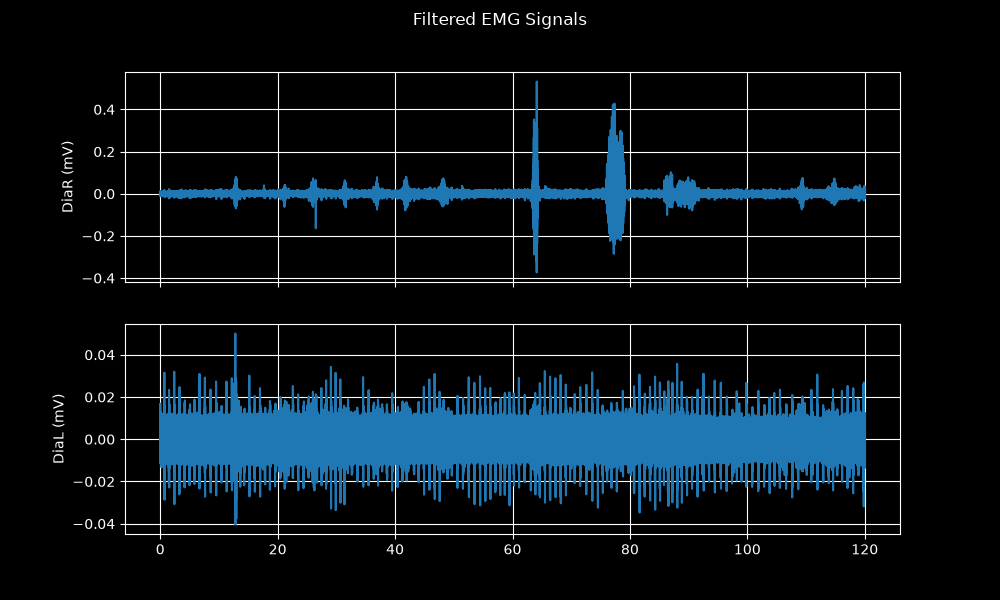

In [6]:
plt.close('all')
emg_timeseries.filter()
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
emg_timeseries.plot_full(axes=axes, signal_io=('filt', ))
fig.suptitle("Filtered EMG Signals")
fig.canvas.header_visible = False
plt.show()

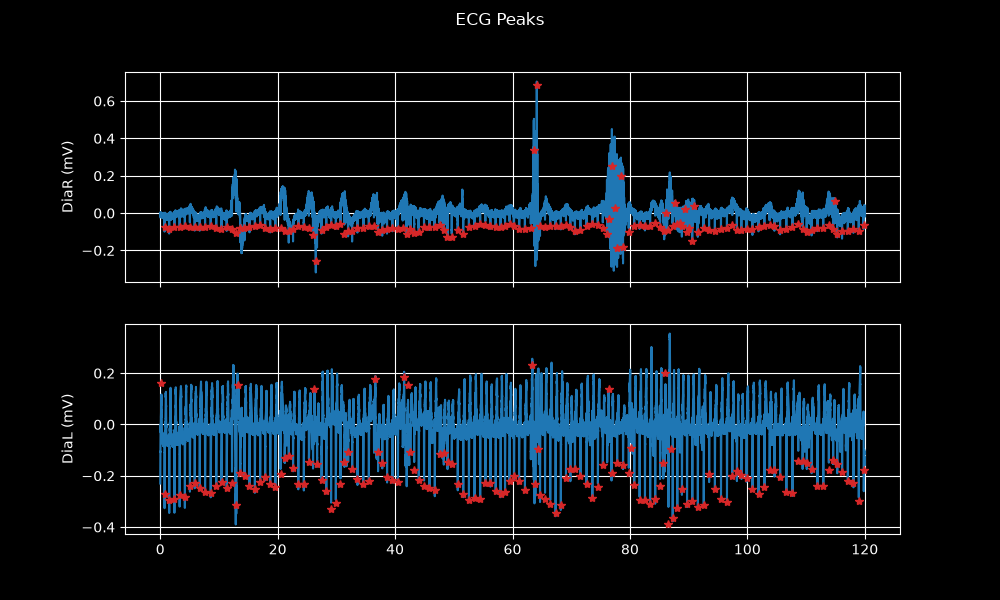

In [7]:
emg_timeseries.get_ecg_peaks(channel_idxs=emg_idx, ecg_raw=None)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

emg_timeseries.plot_full(axes=axes, signal_io=('raw',))
axes=np.transpose([axes])
emg_timeseries.plot_markers(channel_idxs=emg_idx, peak_set_name=["ecg", "ecg"], axes=axes)
fig.suptitle("ECG Peaks")
fig.canvas.header_visible = False

Text(0.5, 0.98, 'Gated EMG Signals')

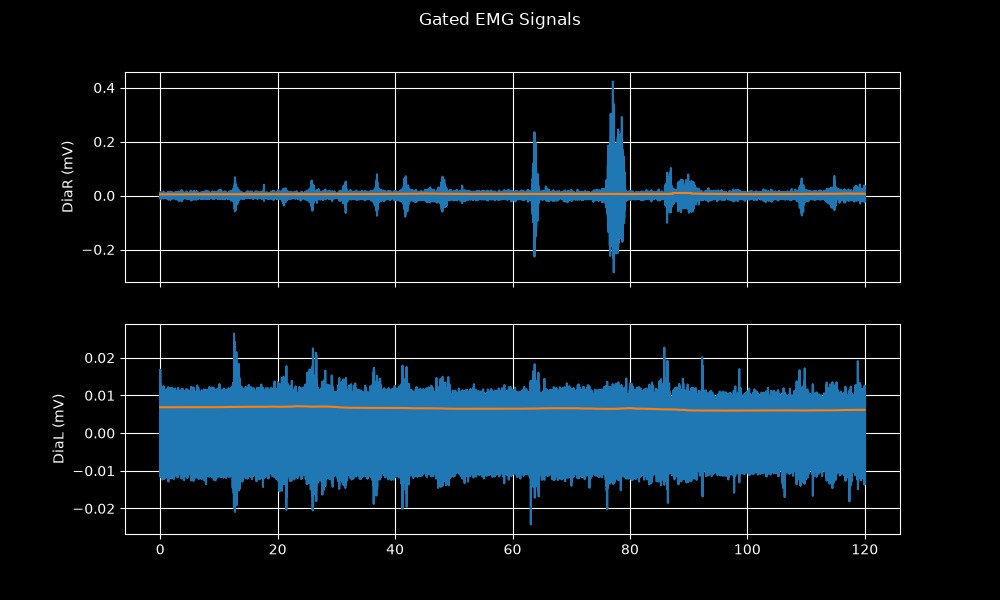

In [13]:
emg_timeseries.gating(channel_idxs=[0])
emg_timeseries.gating(channel_idxs=[0, 1], gate_width_samples=int(emg_timeseries.param['fs']*.2))
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

emg_timeseries.plot_full(axes=axes, signal_io=('clean', ))
fig.canvas.header_visible = False
fig.suptitle("Gated EMG Signals")


Text(0.5, 0.98, 'EMG Envelope Signals')

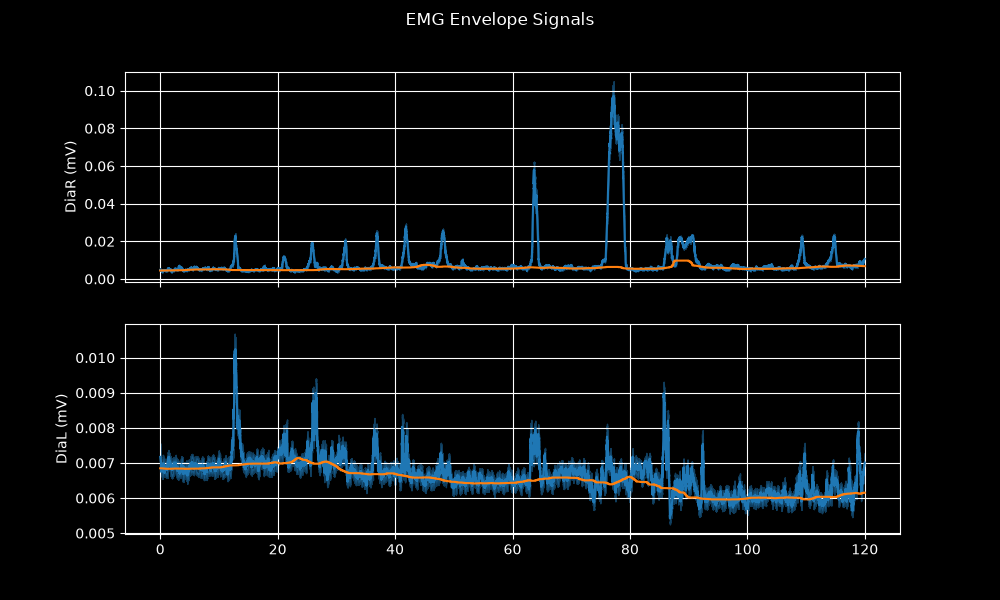

In [14]:
emg_timeseries.envelope(channel_idxs=emg_idx, ci_alpha=.05, env_window_s=int(0.5 * emg_timeseries.param['fs']), ma_window=int(0.05 * emg_timeseries.param['fs']))
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

emg_timeseries.plot_full(axes=axes, signal_io=('env', ), plot_ci=True, )
fig.canvas.header_visible = False
fig.suptitle("EMG Envelope Signals")

Text(0.5, 0.98, 'Baseline')

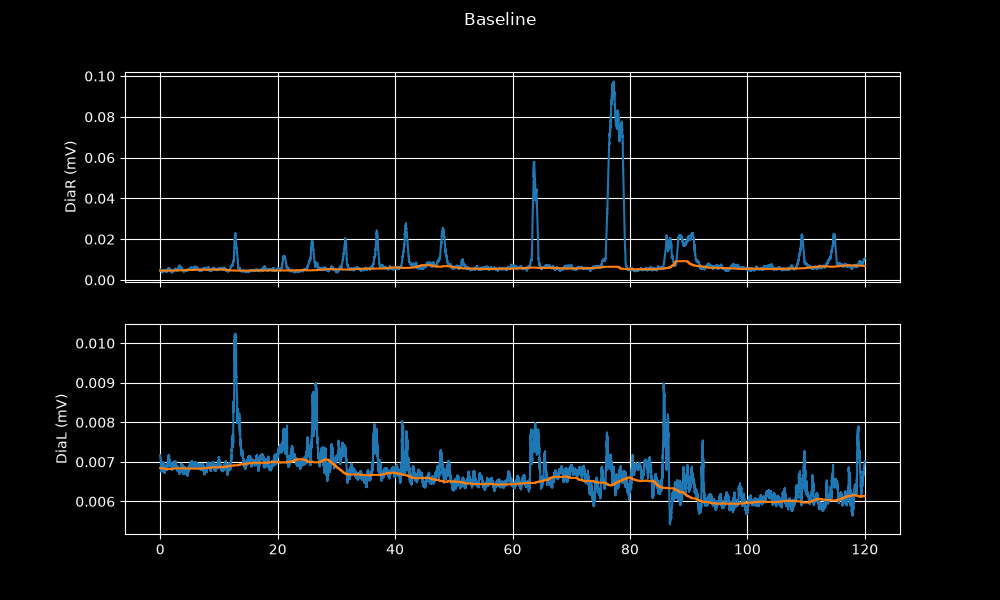

In [16]:
emg_timeseries.baseline(
    channel_idxs=emg_idx,
    base_method="default",
    # base_method="slopesum_baseline"
    # window_s=int(7.5 * emg_timeseries.param["fs"]),
    # ma_window=int(0.5 * emg_timeseries.param["fs"]),
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

emg_timeseries.plot_full(axes=axes, signal_io=('env', ), baseline_bool=True)
fig.canvas.header_visible = False
fig.suptitle("Baseline")

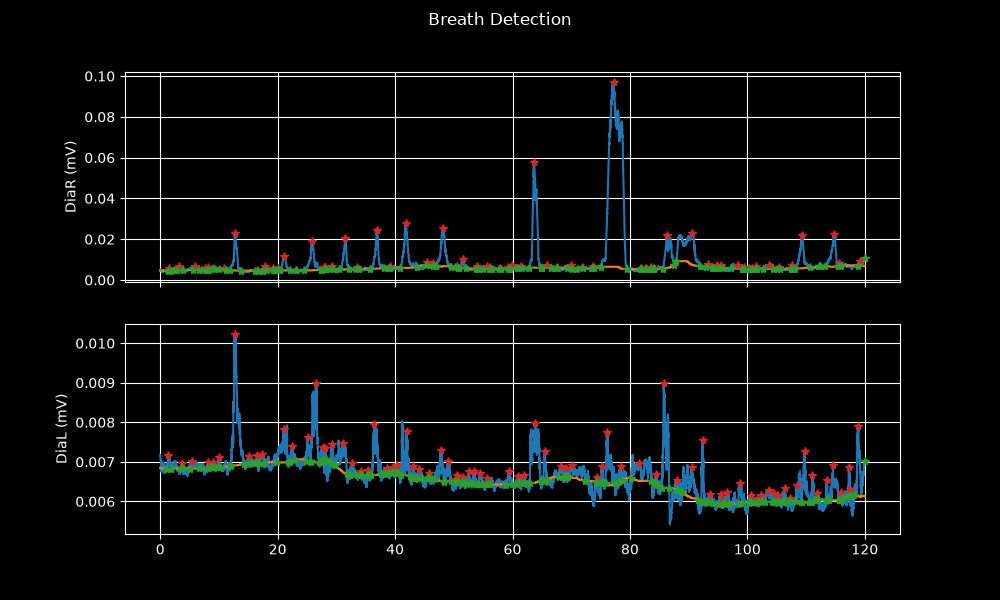

In [17]:
emg_timeseries.detect_emg_breaths(
    channel_idxs=emg_idx,
    # min_peak_width_s=int(0.5 * emg_timeseries.param["fs"]),
    peak_set_name="breaths",
    # prominence_factor=4,
    # min_peak_width_s=.25*emg_timeseries.param["fs"],
    # signal_io=("env", ),
    overwrite=True,
    
    # threshold=.1
)
# get the on and offsets as baseline crossing points
for idx in emg_idx:
    emg_timeseries[idx].peaks["breaths"].detect_on_offset(
        baseline=emg_timeseries[idx]["baseline"],
        fs=emg_timeseries.fs,
        # method="slope_extrapolation",
    )


fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

emg_timeseries.plot_full(axes=axes, signal_io=('env',))
axes=np.transpose([axes])
emg_timeseries.plot_markers(channel_idxs=emg_idx, peak_set_name=["breaths", "breaths"], axes=axes, colors=["tab:red", "tab:green"], valid_only=True)
fig.suptitle("Breath Detection")
fig.canvas.header_visible = False

In [18]:
emg_timeseries.calculate_time_products(
    channel_idxs=emg_idx,
    peak_set_name="breaths",
    include_aub = True,
    aub_window_s = 5*emg_timeseries.param["fs"],
    parameter_name="ETP"
)

for idx in emg_idx:
    emg_timeseries[idx].test_emg_quality(peak_set_name="breaths",
                                        parameter_names={'time_product': 'ETP'},
                                        verbose=False)
    display(emg_timeseries[idx].peaks["breaths"].peak_df)

,peak_idx,start_idx,end_idx,valid,AUB,aub_y_ref,ETP,bell_y_min,bell_a,bell_b,bell_c
0,2891,2488,3735,False,0.000565,0.003685,0.000942,0.003685,0.001723,1.382607,0.658594
1,5259,4787,5768,False,0.000491,0.003685,0.000740,0.003685,0.001672,2.605679,0.440624
2,6550,5857,7696,False,0.000953,0.003685,0.001942,0.003685,0.002692,3.337603,0.516802
3,11675,11088,13121,False,0.001305,0.003685,0.002251,0.003685,0.002572,5.992547,0.747086
4,15331,14356,15952,False,0.000792,0.004063,0.001217,0.004063,0.001747,7.598337,0.609616
...,...,...,...,...,...,...,...,...,...,...,...
69,218549,216358,221492,True,0.003020,0.004618,0.015561,0.004618,0.015100,109.276695,0.522981
70,224592,224430,224693,False,0.000201,0.005154,0.000222,0.005154,0.001760,112.296824,0.199647
71,229461,226550,230940,True,0.002574,0.005401,0.015310,0.005401,0.014698,114.695187,0.553503
72,231363,230943,231735,False,0.000556,0.005401,0.000894,0.005401,0.002756,115.687932,0.246797


,peak_idx,start_idx,end_idx,valid,AUB,aub_y_ref,ETP,bell_y_min,bell_a,bell_b,bell_c
0,2818,2382,3758,False,0.000124,0.006641,0.000245,0.006641,0.000448,1.483663,0.402143
1,7265,7061,7571,False,0.000051,0.006641,0.000069,0.006641,0.000289,3.654925,0.289412
2,10844,9973,13268,False,0.000314,0.006641,0.000466,0.006641,0.000303,5.661779,1.837367
3,16252,15967,16989,False,0.000106,0.006641,0.000145,0.006641,0.000296,8.226508,0.729674
4,18000,17402,18452,False,0.000117,0.006641,0.000155,0.006641,0.000319,8.982790,0.534698
...,...,...,...,...,...,...,...,...,...,...,...
88,231885,231413,232153,False,0.000154,0.005638,0.000190,0.005638,0.000541,115.932057,0.482468
89,234523,234141,235015,False,0.000218,0.005638,0.000371,0.005638,0.001059,117.351438,0.277717
90,235064,235049,235140,False,0.000023,0.005638,0.000025,0.005638,0.001146,117.032001,0.606907
91,236791,236432,239999,False,0.000890,0.005638,0.002004,0.005638,0.001310,118.895500,1.339745
